In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('data/oecd_tourism.csv', usecols=['LOCATION', 'SUBJECT', 'TIME', 'Value'])
df

,LOCATION,SUBJECT,TIME,Value
0,AUS,INT_REC,2008,31159.800
1,AUS,INT_REC,2009,29980.700
2,AUS,INT_REC,2010,35165.500
3,AUS,INT_REC,2011,38710.100
4,AUS,INT_REC,2012,38003.700
...,...,...,...,...
1229,SRB,INT-EXP,2015,1253.644
1230,SRB,INT-EXP,2016,1351.098
1231,SRB,INT-EXP,2017,1549.183
1232,SRB,INT-EXP,2018,1837.317


In [11]:
for col in df.columns:
    print(f'{col}: {df[col].unique()}')

LOCATION: ['AUS' 'AUT' 'BEL' 'CAN' 'CZE' 'DNK' 'FIN' 'FRA' 'DEU' 'GRC' 'HUN' 'ISL'
 'IRL' 'ITA' 'JPN' 'KOR' 'LUX' 'MEX' 'NLD' 'NZL' 'NOR' 'POL' 'PRT' 'SVK'
 'ESP' 'SWE' 'CHE' 'TUR' 'GBR' 'USA' 'BRA' 'BGR' 'CHL' 'COL' 'CRI' 'HRV'
 'EGY' 'EST' 'IND' 'IDN' 'ISR' 'LVA' 'LTU' 'MLT' 'MAR' 'PER' 'PHL' 'ROU'
 'RUS' 'SVN' 'ZAF' 'CHN' 'KAZ' 'SRB']
SUBJECT: ['INT_REC' 'INT-EXP']
TIME: [2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019]
Value: [31159.8   29980.7   35165.5   ...  1549.183  1837.317  1999.313]


In [12]:
len(df) - df.count()

LOCATION    0
SUBJECT     0
TIME        0
Value       0
dtype: int64

In [15]:
df.loc[df['SUBJECT'] == 'INT_REC', ['LOCATION', 'Value']].groupby('LOCATION')['Value'].sum().sort_values(ascending=False).head(5)

LOCATION
USA    2419362.000
ESP     766213.991
FRA     715696.693
DEU     587494.277
GBR     569273.000
Name: Value, dtype: float64

In [16]:
df.loc[df['SUBJECT'] == 'INT-EXP', ['LOCATION', 'Value']].groupby('LOCATION')['Value'].sum().sort_values(ascending=True).head(5)

LOCATION
MLT     4653.620
LVA    10115.000
CRI    10404.900
LTU    10709.400
ISL    11801.016
Name: Value, dtype: float64

In [21]:
locations = pd.read_csv('data/oecd_locations.csv', header=None, names=['LOCATION', 'Full_name'])
locations

,LOCATION,Full_name
0,AUS,Australia
1,AUT,Austria
2,BEL,Belgium
3,CAN,Canada
4,DNK,Denmark
5,FIN,Finland
6,FRA,France
7,DEU,Germany
8,HUN,Hungary
9,ITA,Italy


In [22]:
locations = locations.set_index(keys=['LOCATION']).sort_index()

In [23]:
locations.head()

,Full_name
LOCATION,
AUS,Australia
AUT,Austria
BEL,Belgium
BRA,Brazil
CAN,Canada


In [24]:
df.head()

,LOCATION,SUBJECT,TIME,Value
0,AUS,INT_REC,2008,31159.8
1,AUS,INT_REC,2009,29980.7
2,AUS,INT_REC,2010,35165.5
3,AUS,INT_REC,2011,38710.1
4,AUS,INT_REC,2012,38003.7


In [25]:
df = df.set_index(keys=['LOCATION']).sort_index()

In [26]:
df.head()

,SUBJECT,TIME,Value
LOCATION,,,
AUS,INT_REC,2008,31159.8
AUS,INT-EXP,2019,41452.0
AUS,INT-EXP,2018,42478.0
AUS,INT-EXP,2017,39644.9
AUS,INT-EXP,2016,35674.6


In [27]:
joined = df.join(locations)
joined

,SUBJECT,TIME,Value,Full_name
LOCATION,,,,
AUS,INT_REC,2008,31159.800,Australia
AUS,INT-EXP,2019,41452.000,Australia
AUS,INT-EXP,2018,42478.000,Australia
AUS,INT-EXP,2017,39644.900,Australia
AUS,INT-EXP,2016,35674.600,Australia
...,...,...,...,...
ZAF,INT_REC,2010,10308.600,NaN
ZAF,INT_REC,2015,9139.363,NaN
ZAF,INT_REC,2012,11201.690,NaN


In [28]:
joined.loc[joined['SUBJECT'] == 'INT_REC', ['Full_name', 'Value']].groupby('Full_name')['Value'].sum().sort_values(ascending=False).head(5)

Full_name
United States     2419362.000
France             715696.693
Germany            587494.277
United Kingdom     569273.000
Italy              494232.327
Name: Value, dtype: float64

In [32]:
joined.loc[joined['SUBJECT'] == 'INT-EXP', ['Full_name', 'Value']].groupby('Full_name')['Value'].sum().sort_values(ascending=True).head(5)

Full_name
Hungary     32102.292
Finland     64647.890
Israel      80718.298
Denmark    124587.866
Austria    131280.200
Name: Value, dtype: float64

In [33]:
locations.loc['MLT']

KeyError: 'MLT'

In [34]:
# 31.1

In [35]:
joined_new = locations.join(df)
joined_new

,Full_name,SUBJECT,TIME,Value
LOCATION,,,,
AUS,Australia,INT_REC,2008,31159.8
AUS,Australia,INT-EXP,2019,41452.0
AUS,Australia,INT-EXP,2018,42478.0
AUS,Australia,INT-EXP,2017,39644.9
AUS,Australia,INT-EXP,2016,35674.6
...,...,...,...,...
USA,United States,INT_REC,2012,195114.0
USA,United States,INT-EXP,2019,182365.0
USA,United States,INT_REC,2008,149095.0


In [36]:
joined_new.loc[joined_new['SUBJECT'] == 'INT_REC', ['Full_name', 'Value']].groupby('Full_name')['Value'].sum().sort_values(ascending=False).head(5)

Full_name
United States     2419362.000
France             715696.693
Germany            587494.277
United Kingdom     569273.000
Italy              494232.327
Name: Value, dtype: float64

In [37]:
joined_new.loc[joined_new['SUBJECT'] == 'INT-EXP', ['Full_name', 'Value']].groupby('Full_name')['Value'].sum().sort_values(ascending=True).head(5)

Full_name
Hungary     32102.292
Finland     64647.890
Israel      80718.298
Denmark    124587.866
Austria    131280.200
Name: Value, dtype: float64

In [38]:
joined

,SUBJECT,TIME,Value,Full_name
LOCATION,,,,
AUS,INT_REC,2008,31159.800,Australia
AUS,INT-EXP,2019,41452.000,Australia
AUS,INT-EXP,2018,42478.000,Australia
AUS,INT-EXP,2017,39644.900,Australia
AUS,INT-EXP,2016,35674.600,Australia
...,...,...,...,...
ZAF,INT_REC,2010,10308.600,NaN
ZAF,INT_REC,2015,9139.363,NaN
ZAF,INT_REC,2012,11201.690,NaN


In [41]:
joined.groupby('Full_name').count()

,SUBJECT,TIME,Value
Full_name,,,
Australia,24,24,24
Austria,22,22,22
Belgium,22,22,22
Brazil,24,24,24
Canada,24,24,24
Denmark,22,22,22
Finland,22,22,22
France,22,22,22
Germany,22,22,22


In [42]:
# 31.2

<Axes: xlabel='TIME'>

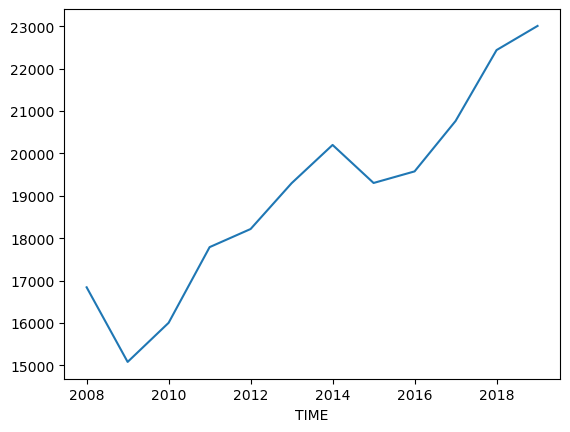

In [45]:
df.loc[df['SUBJECT'] == 'INT_REC', ['TIME', 'Value']].groupby('TIME')['Value'].mean().plot()

In [46]:
# 31.3

In [48]:
locations = locations.reset_index()

In [49]:
locations

,LOCATION,Full_name
0,AUS,Australia
1,AUT,Austria
2,BEL,Belgium
3,BRA,Brazil
4,CAN,Canada
5,DEU,Germany
6,DNK,Denmark
7,FIN,Finland
8,FRA,France
9,GBR,United Kingdom


In [50]:
joined_v2 = locations.join(df, on='LOCATION')
joined_v2

,LOCATION,Full_name,SUBJECT,TIME,Value
0,AUS,Australia,INT_REC,2008,31159.8
0,AUS,Australia,INT-EXP,2019,41452.0
0,AUS,Australia,INT-EXP,2018,42478.0
0,AUS,Australia,INT-EXP,2017,39644.9
0,AUS,Australia,INT-EXP,2016,35674.6
...,...,...,...,...,...
15,USA,United States,INT_REC,2012,195114.0
15,USA,United States,INT-EXP,2019,182365.0
15,USA,United States,INT_REC,2008,149095.0
15,USA,United States,INT_REC,2010,161821.0
